# **TECNICATURA UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL**  
## TRABAJO PRÁCTICO N° 2: MINERÍA DE DATOS  
### **INTEGRANTES:** Grimaldi, Damián - (G-5977/3) | 
### **Fecha Límite de Entrega:** 25/9/2026
### **Semestre:** 2° Semestre 2026

# Objetivo

Cuyo objetivo es aplicar tecnicas de mineria de datos sobre nuestra ***variable objetivo*** (Especie)

# Dataset

Se utiliza el dataset de `penguins_size.csv`.
* Especie: Nuestra variable objetivo, es de tipo String, que cuenta con 3 tipos de pinguinos distintos.
* Longuitud Culmen (mm): variable numerica, que nos indica el largo del pico. .
* Profundidad Culmen(mm): variable númerica, que nos indica la altura/profundidad del pico.
* Longitud Aleta (mm): variable numerica, que nos indica la longuitud de la aleta de los difersos pinguinos.
* Masa coporal (g) : variable numerica, que nos indica el peso del pinguino.
* Sexo: Varibale categorica, que nos indica con MALE y con FEMALE.

# Librerias a utilizar

In [1]:
# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import seaborn as sns

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split

# sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, Isomap, TSNE

# Algoritmos de clustering
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage

# Métricas
from sklearn.metrics import silhouette_score,silhouette_samples

# Carga del dataset

In [2]:
pinguinos = pd.read_csv("penguins_size.csv", sep=";")
pinguinos.drop(columns= ["Unnamed: 6", "Unnamed: 7"], inplace=True)
pinguinos.head()

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
0,Adelie Penguin,39.1,18.7,181.0,3750.0,MALE
1,Adelie Penguin,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie Penguin,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie Penguin,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin,36.7,19.3,193.0,3450.0,FEMALE


# Analisis Exploratorio

In [3]:
pinguinos.info()

<class 'pandas.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  347 non-null    str    
 1   Longitud Culmen (mm)     345 non-null    float64
 2   Profundidad Culmen (mm)  345 non-null    float64
 3   Longitud Aleta (mm)      345 non-null    float64
 4   Masa corporal (g)        345 non-null    float64
 5   Sexo                     337 non-null    str    
dtypes: float64(4), str(2)
memory usage: 16.4 KB


Contiene un total de 347 filas, con 6 columnas. Con la unica columna completa es la de Especie, las demas contiene elemeentos faltantes

In [4]:
pinguinos.describe()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
count,345.000000,345.000000,345.000000,345.000000
mean,43.944348,17.155072,200.944928,4203.985507
std,5.510041,1.967138,14.106113,806.232797
min,32.100000,13.100000,172.000000,2700.000000
25%,39.200000,15.600000,190.000000,3550.000000
50%,44.400000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


Con estos valores, a priori, no se logra observar que las distribución tengan valores atipico, y que estan relacionadas las metricas que pueden tener las 3 especies

In [5]:
pinguinos.duplicated().sum()

np.int64(3)

Cuenta con 3 culumnas duplicadas, por lo cual, a estos, tenemos que elimnar las duplicadas

In [6]:
pinguinos.drop_duplicates(inplace=True)
pinguinos.duplicated().sum()

np.int64(0)

### Variable Objetivo, Especie

In [7]:
pinguinos["Especie"].value_counts()

Especie
Adelie Penguin       152
Gentoo penguin       124
Chinstrap penguin     68
Name: count, dtype: int64

Cuenta unicamente con 3 especies de pinguinos, se decide estandarizar las especies, unicamente en el nombre, eliminando penguin, para dejarlos estandarizados en el miso formato.
Ademas, se ve que hay más elementos, en Adelie, como la mayor clase, y con la menor, con la de Chinstrap.

In [8]:
pinguinos['Especie'] = pinguinos['Especie'].str.replace(r'\s*[Pp]enguin', '', regex=True)

pinguinos['Especie'].value_counts()

Especie
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Text(0, 0.5, 'Frecuencia')

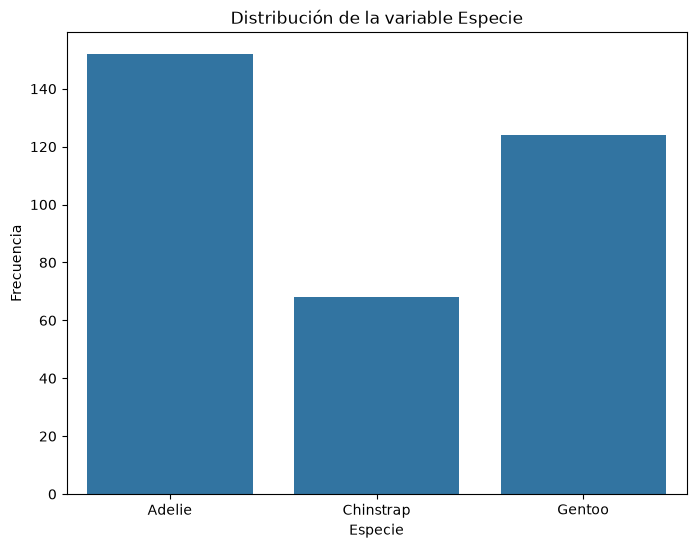

In [9]:
# Grafico de distribucion de la variable Especie
plt.figure(figsize=(8, 6))
sns.countplot(data=pinguinos, x='Especie')
plt.title('Distribución de la variable Especie')
plt.xlabel('Especie')
plt.ylabel('Frecuencia')

Ya visualiando la columna de Especie, se puede apreciar de mejor manera, la distribución desbalanceada de cada especie.

## Tratamiento de nulos

In [10]:
pinguinos[pinguinos.isnull().any(axis=1)]

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
3,Adelie,NaN,NaN,NaN,NaN,NaN
8,Adelie,34.1,18.1,193.0,3475.0,NaN
9,Adelie,42.0,20.2,190.0,4250.0,NaN
10,Adelie,37.8,17.1,186.0,3300.0,NaN
11,Adelie,37.8,17.3,180.0,3700.0,NaN
47,Adelie,37.5,18.9,179.0,2975.0,NaN
248,Gentoo,44.5,14.3,216.0,4100.0,NaN
289,Gentoo,46.2,14.4,214.0,4650.0,NaN
327,Gentoo,47.3,13.8,216.0,4725.0,NaN
342,Gentoo,NaN,NaN,NaN,NaN,NaN


Aca se puede observar de mejor manera, que solamente hay dos filas en donde los valores de las columnas numericas, estan como nulas, posible tratamiento para esto, es agruparlas en función de su correlación.

### Tratamiento de la columna Sexo

In [11]:
pinguinos["Sexo"].value_counts()

Sexo
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

Se observa que hay un unico valor atipico para la variable sexo, que en este caso esta con ".", de la cual puede ser un error de tipeo. Por lo que hay que hacer, es eliminar ese valor, y reemplazarlo por la moda.\
Tambien se observa, cuenta con mayoritariamente, pingunos masculinos.

In [12]:
moda_sexo = pinguinos["Sexo"].mode()[0]

pinguinos.loc[pinguinos["Sexo"] == ".", "Sexo"] = np.nan

pinguinos.loc[pinguinos["Sexo"].isnull(), "Sexo"] = moda_sexo
pinguinos["Sexo"].value_counts()

Sexo
MALE      179
FEMALE    165
Name: count, dtype: int64

## Grafico de distribuciones

### Matriz de correlación

In [13]:
columnas_numericas = ["Longitud Culmen (mm)", "Profundidad Culmen (mm)", "Longitud Aleta (mm)", "Masa corporal (g)"]
columnas_categoricas = "Sexo"

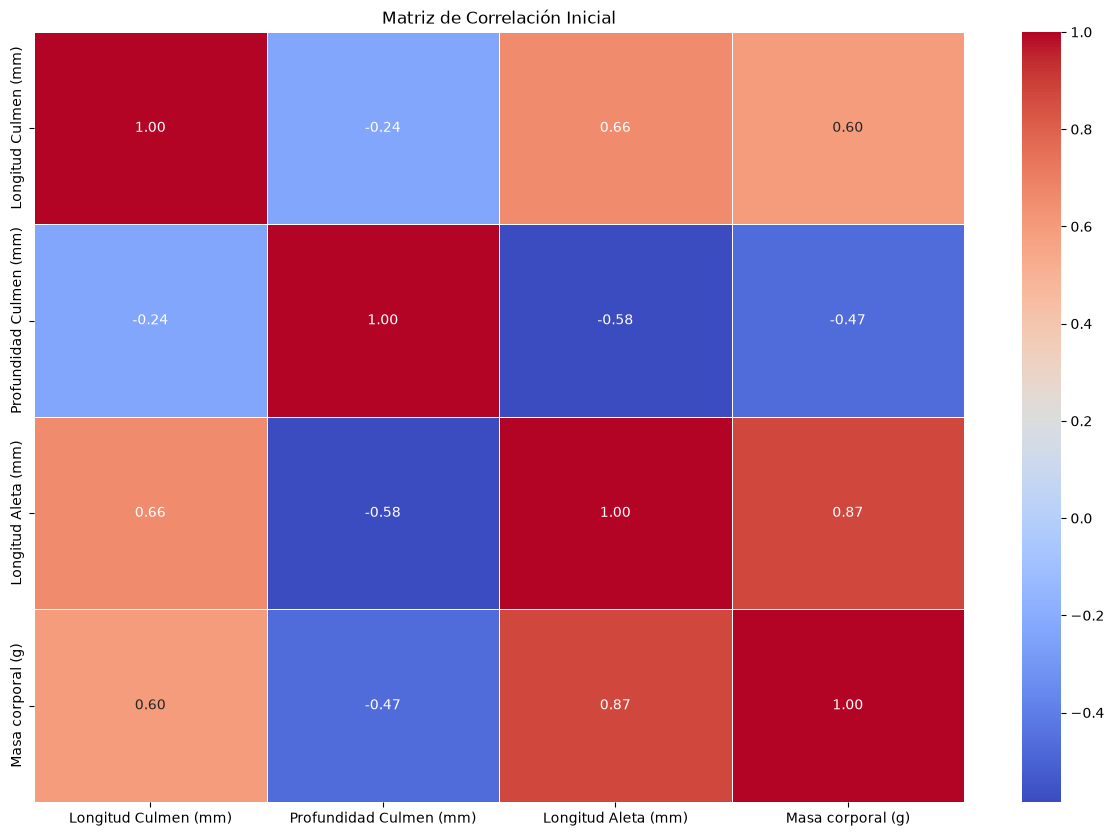

In [14]:
plt.figure(figsize=(15, 10))
correlation_matrix = pinguinos[columnas_numericas].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación Inicial")
plt.show()

* Masa corporal (g) con Longitud Aleta (mm), tienen una relación positiva muy fuerte.
* Masa corpotal (g) con Longitud Culmen (mm), tiene una realacion postiva moderada.
* Masa corpotal (g) con Porfundidad Culmen (mm), tienen una relacion negativa debil.

* Longitud de Aleta (mm) con Longitud Culmen (mm), tienen una relacion positiva moderada.
* Profundidad Culmen (mm) con Longitud Aleta (mm), tienen una relacion negativa moderada.